# Programming assignment 5: Dermatological image classification
- PA5 Group 4 Members:
  
  1. Zheng Wei Liau (liau@chalmers.se)
  2. Jared Ng (jaredn@chalmers.se)

Assignment Objectives:
1. Classify images of skin lesions as melanoma (deadly) or nevus (harmless)
2. Write technical report describing solution and results

### Sample Code that selects 8 random images and displays them in the notebook using plt.imshow
- Adjust the directory to where you extracted the files
- Transpose is needed as RGB dimension comes before the height and width diemnsions in PyTorch/Torchvision, plt.imshow requires RGB dimension to go last

In [1]:
import torch
import torchvision

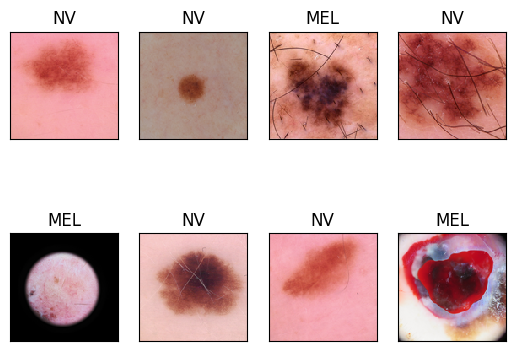

In [2]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

folder = ImageFolder('PA5/train', transform=torchvision.transforms.ToTensor())
loader = DataLoader(folder, batch_size=8, shuffle=True)
Xexamples, Yexamples = next(iter(loader))

for i in range(8):
  plt.subplot(2,4,i+1)
  img = Xexamples[i].numpy().transpose(1,2,0)
  plt.imshow(img, interpolation='none')
  plt.title('NV' if Yexamples[i] else 'MEL')
  plt.xticks([])
  plt.yticks([])

### Explainer: working with pre trained models in PyTorch/Torchvision
- choice of fine tuning pre trained model or not (do not update the weights of the original model and just apply as a feature extractor)
  - encouraged to use frozen model despite more probably lower accuracy



### Example: Loading VGG-16 model
- trained on a part of ImageNet dataset comprising of 1000 categories of various everyday objects
- early model BUT applicable with most hardware

In [3]:
weights_id = torchvision.models.VGG16_Weights.IMAGENET1K_V1
vggmodel = torchvision.models.vgg16(weights=weights_id)
vggmodel.eval()
vggtransforms = weights_id.transforms()

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /data/users/liau/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:01<00:00, 519MB/s] 


### Comments on the above code
- First time execution: model weights downloaded from a repository. Weights cached if you run the code again
- model can be initialised with different set of weights . weights_id used to identify which weights to use, in this case its the weights of the model pre trained on ImageNet
- .eval() is called to set components like dropout and batch normalisation to "evaluation mode" as model is not being trained now
- vggtransform tracks image preprocessing that was used when the model was trained. You can use it as part of your transform pipeline for ImageFolder. For pre trained iamge model, use appropriate preprocessing, else it may confuse the model when applying it.


In [4]:
# Code to print the vggmodel
print(vggmodel)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### Comments Continued(1)
- The vggmodel is a pipeline consisting of a "feature extractor" (convolutional part) followed by a fully connected neural network classifier
- To apply the feature extractor by itself, call vggmodel.features(X) where X is a batch of images. Output is then used as the input for a smaller model that we train for our specific task

Hint: When using a frozen model as a feature extractor, simply run it once on each of the datasets (training, validation and test parts) and save the results to a file (using np.save) so it can be reloaded. Applying a large model is time consuming so reusing precomputed results will be much faster than applying the model many times

Hint: If memory problems are encountered, turn off gradient computation (gradient descent updates are not applied to the parameters of this model). Do this by calling .detach() on the output tensor to get rid of its computational graph, or call the model is a torch.no_grad() block:

In [5]:
#with torch.no_grad():
#  ... apply the model ...

### Comments Continued(2)
Note: Other pre trained models might have different structures and might need to be called a different way

### Task 1: Explore different solutions and evaluate on validation set
1. Create ML image classifier and train on training set
2. Explore and compare different solutions and evaluate them on the validation set
3. use accuracy score as performance metric to compare different solutions
- To Use:

  1) Normalisation: batch normalisation, layer normalisation, group normalisation

  2) Residual connections

  3) Data Augmentation: random transformation to images

  4) Transfer Learning: pre trained model

  - To see if each of these methods gives an improvement over a baseline that does not use it

  - Dataset is balanced so should not have an accuracy of around 0.5

  - Use any method except:

    1. Systems that already classify skin marks
    2. API based services that cannot be run locally



### Workflow:
1. Train baseline model and validate results
2. Train baseline + normalisation and validate results
3. Train baseline + residual connections and validate results
4. Train baseline + data augmentation and validate results
5. Train Transfer Learning model and validate results
6. Compare the results of all the different model combinations to determine the best model combination.
7. Test the best model combination on the test set

# 1. Baseline Model

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
import os

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # (32,112,112)
        x = self.pool(F.relu(self.conv2(x))) # (64,56,56)
        x = x.view(x.size(0), -1)            # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes=3).to(device)

In [9]:
# Transforms without augmentation
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load Dataset
train_dir = 'PA5/train'
val_dir = 'PA5/val'
test_dir = 'PA5/test'

train_dataset = datasets.ImageFolder(train_dir, transform=basic_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=basic_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=basic_transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)

In [10]:
# Initialise Model, Loss, Optimiser
model = SimpleCNN(num_classes=num_classes).to(device)

criterioon = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [11]:
# Train the model
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterioon(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/5], Loss: 0.5683
Epoch [2/5], Loss: 0.4142
Epoch [3/5], Loss: 0.3828
Epoch [4/5], Loss: 0.3851
Epoch [5/5], Loss: 0.3494


In [12]:
# Evaluate the val set
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy on validation set: {100 * correct / total}%")

Accuracy on validation set: 80.59105431309904%


In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

<Figure size 800x600 with 0 Axes>

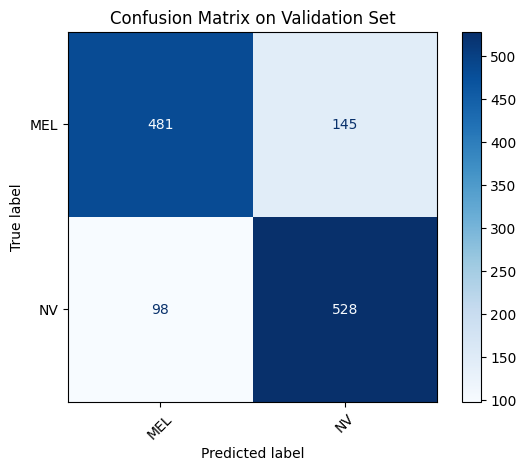

In [15]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=val_dataset.classes)

plt.figure(figsize=(8,6))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix on Validation Set")
plt.show()

# 2. Baseline Model with Normalisation

In [16]:
from torchvision import datasets
from torch.utils.data import DataLoader

normalised_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(train_dir, transform=normalised_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=normalised_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=normalised_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [17]:
num_classes = len(train_dataset.classes)

# Initialise Model, Loss, Optimiser
model = SimpleCNN(num_classes=num_classes).to(device)

criterioon = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [18]:
print("Number of classes in train dataset:", num_classes)

Number of classes in train dataset: 2


In [19]:
# Train the model
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterioon(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/5], Loss: 0.5830
Epoch [2/5], Loss: 0.3719
Epoch [3/5], Loss: 0.3337
Epoch [4/5], Loss: 0.2890
Epoch [5/5], Loss: 0.2345


In [20]:
# Evaluate the val set
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy on validation set: {100 * correct / total}%")

Accuracy on validation set: 80.59105431309904%


<Figure size 800x600 with 0 Axes>

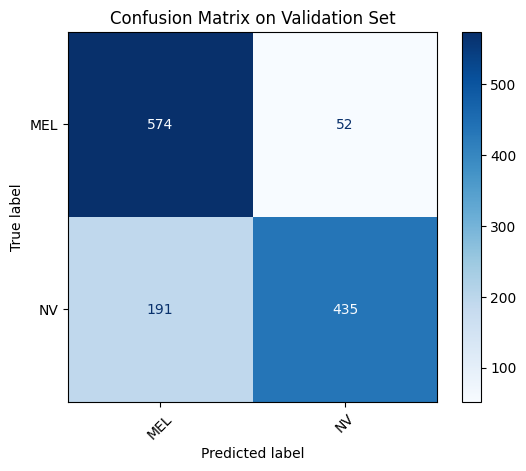

In [21]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=val_dataset.classes)

plt.figure(figsize=(8,6))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix on Validation Set")
plt.show()

# 3. Baseline Model with Residual Connections

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [23]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms 
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)

In [24]:
# Residual Block
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x):
        residual = x
        out = F.relu(self.conv1(x))
        out = self.conv2(out)
        out += residual
        return F.relu(out)
        
# Simple CNN with Residual connections
class ResidualCNN(nn.Module):
    def __init__(self, num_classes):
        super(ResidualCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.layer1 = ResidualBlock(64, 64)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.layer2 = ResidualBlock(128, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc1 = nn.Linear(128 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.layer1(x)
        x = self.pool(x)               # (64,112,112)
        
        x = F.relu(self.conv2(x))
        x = self.layer2(x)
        x = self.pool2(x)              # (128,56,56)
        
        x = x.view(x.size(0), -1)      # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [25]:
# Initialise Model, Loss, Optimiser
model = ResidualCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [26]:
# Train the model
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/5], Loss: 0.6747
Epoch [2/5], Loss: 0.4382
Epoch [3/5], Loss: 0.4336
Epoch [4/5], Loss: 0.4172
Epoch [5/5], Loss: 0.3963


In [27]:
# Validate the model
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
print(f"Accuracy on validation set: {100 * correct / total}%")

Accuracy on validation set: 79.7923322683706%


<Figure size 800x600 with 0 Axes>

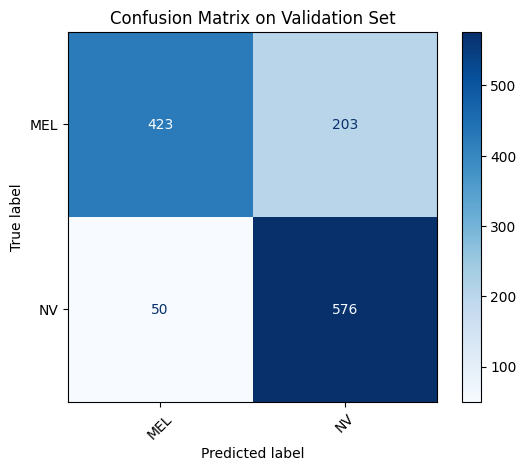

In [28]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=val_dataset.classes)
plt.figure(figsize=(8,6))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix on Validation Set")
plt.show()

# 4. Baseline Model with Data Augmentation

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [30]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms with Data Augmentation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop((224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)

In [31]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # (32,112,112)
        x = self.pool(F.relu(self.conv2(x))) # (64,56,56)
        x = x.view(x.size(0), -1)            # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [32]:
# Initialise Model, Loss, Optimiser
model = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [33]:
# Train the model
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/5], Loss: 0.6376
Epoch [2/5], Loss: 0.5325
Epoch [3/5], Loss: 0.5131
Epoch [4/5], Loss: 0.5025
Epoch [5/5], Loss: 0.4925


In [34]:
# Validate the model
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
print(f"Accuracy on validation set: {100 * correct / total}%")

Accuracy on validation set: 76.43769968051119%


<Figure size 800x600 with 0 Axes>

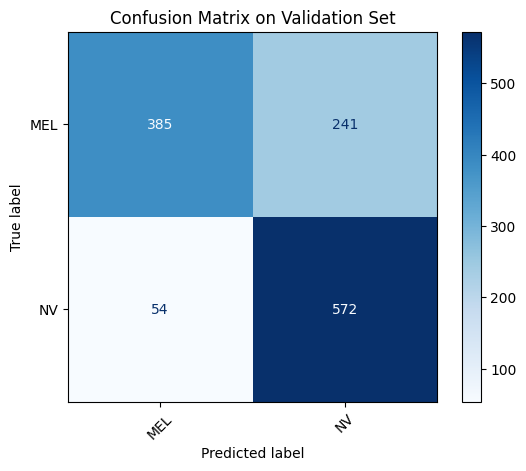

In [35]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=val_dataset.classes)
plt.figure(figsize=(8,6))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix on Validation Set")
plt.show()

# 5. Transfer Learning Model

In [36]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [37]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)

In [38]:
# Load pre-trained VGG16 model
vggmodel = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Freeze all convolutional layers
for param in vggmodel.features.parameters():
    param.requires_grad = False
    
# Replace the classifier with a new one
vggmodel.classifier[6] = nn.Linear(4096, num_classes)
vggmodel = vggmodel.to(device)

# Loss and Optimiser
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vggmodel.parameters(), lr=0.001)

In [39]:
# Training the model
num_epochs = 5
for epoch in range(num_epochs):
    vggmodel.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vggmodel(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/5], Loss: 0.4827
Epoch [2/5], Loss: 0.3883
Epoch [3/5], Loss: 0.3135
Epoch [4/5], Loss: 0.2604
Epoch [5/5], Loss: 0.2397


In [40]:
# Validate the model
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
print(f"Accuracy on validation set: {100 * correct / total}%")

Accuracy on validation set: 76.43769968051119%


<Figure size 800x600 with 0 Axes>

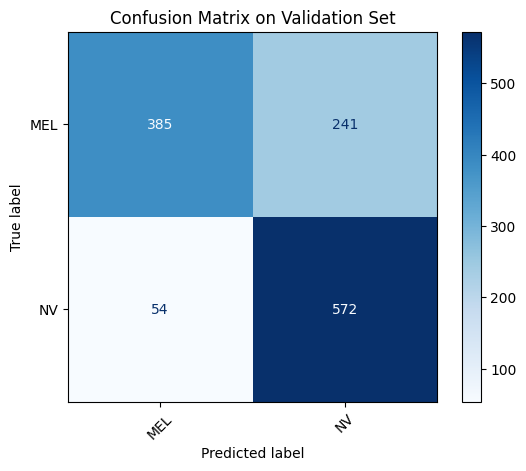

In [41]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=val_dataset.classes)
plt.figure(figsize=(8,6))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix on Validation Set")
plt.show()

### Task 2: Compute the accuracy score on test set
- Compute the score on the test set with labels and include in the report

Note: Discussion on technical choices should be based on validation set results and there is only 1 test set score




-- Based on the results on the validation sets, both the Baseline Model and the Baseline Model with Normalisation have the same validation accuracy of 80.591%. Given that Batch Normalisation can help models be more robust to noise, we decided to choose the Baseline Model with Normalisation over just the Baseline Model in the case whereby the validation accuracy of only using the Baseline Model is a fluke.

In [42]:
from torchvision import datasets
from torch.utils.data import DataLoader

normalised_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(train_dir, transform=normalised_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=normalised_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=normalised_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [43]:
num_classes = len(train_dataset.classes)

# Initialise Model, Loss, Optimiser
model = SimpleCNN(num_classes=num_classes).to(device)

criterioon = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [44]:
# Train the model
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterioon(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/5], Loss: 0.5568
Epoch [2/5], Loss: 0.3999
Epoch [3/5], Loss: 0.3563
Epoch [4/5], Loss: 0.3359
Epoch [5/5], Loss: 0.2789


In [45]:
# Evaluate the test set
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy on test set: {100 * correct / total}%")

Accuracy on test set: 81.11273792093704%


<Figure size 800x600 with 0 Axes>

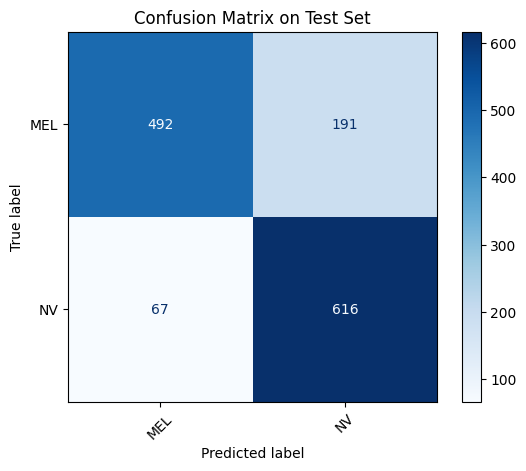

In [46]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=test_dataset.classes)

plt.figure(figsize=(8,6))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.show()